# Chapter 15 — PCA and SVD

**Goals**

- Implement PCA via SVD from scratch in NumPy.
- Reproduce `sklearn.decomposition.PCA` on the Digits dataset.
- Plot the cumulative explained-variance curve and choose $k$.
- Visualize Digits in 2D — see classes naturally separate.
- Use PCA as a preprocessing step for KNN; quantify the speed-accuracy trade-off.

Pair with `docs/08_dimensionality_reduction.md`.

## 1. Setup

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. PCA via SVD from scratch

1. Centre the data.
2. SVD of the centred matrix.
3. The columns of $\mathbf{U}$ are the principal directions; singular values give variances.

In [2]:
def pca_fit(X, n_components):
    mean = X.mean(axis=0, keepdims=True)
    Xc = X - mean
    V, S, UT = np.linalg.svd(Xc, full_matrices=False)
    components = UT[:n_components]                   # shape (k, d)
    explained_variance = (S[:n_components] ** 2) / (X.shape[0] - 1)
    return mean, components, explained_variance, S

def pca_transform(X, mean, components):
    return (X - mean) @ components.T                 # shape (n, k)

## 3. Load Digits + standardize

In [3]:
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

## 4. Fit our scratch PCA and compare with sklearn

In [4]:
k = 10
mean_, comps_, ev_, sing_ = pca_fit(X_train_s, n_components=k)
scratch_train_pcs = pca_transform(X_train_s, mean_, comps_)
scratch_test_pcs  = pca_transform(X_test_s,  mean_, comps_)

sk = PCA(n_components=k, random_state=SEED).fit(X_train_s)
sk_train_pcs = sk.transform(X_train_s)
sk_test_pcs  = sk.transform(X_test_s)

print('Component signs may flip between implementations. Check |abs| agreement:')
print('train PCs absolute diff:', np.abs(np.abs(scratch_train_pcs) - np.abs(sk_train_pcs)).max())

Component signs may flip between implementations. Check |abs| agreement:
train PCs absolute diff: 1.6928680679484387e-12


## 5. Explained variance ratio + choose K

components needed to explain 95% variance = 40


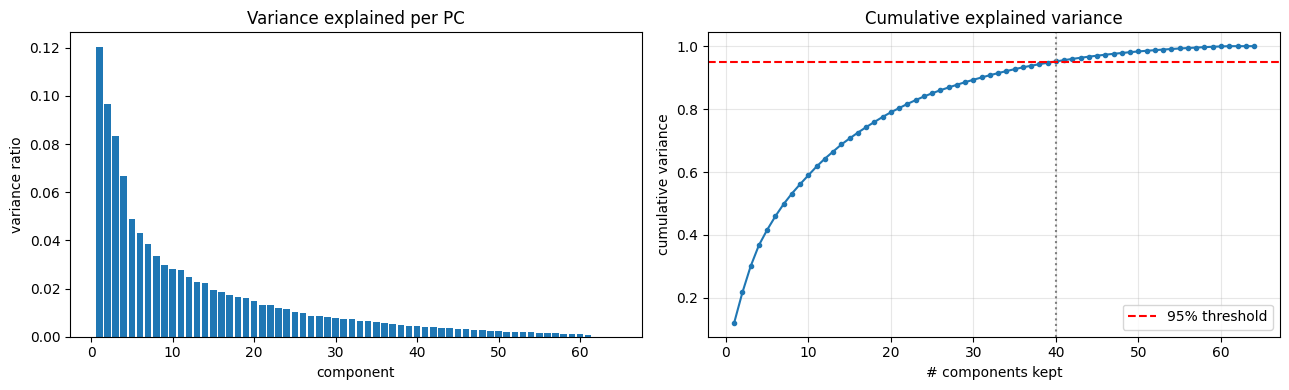

In [5]:
_, comps_full, ev_full, sing_full = pca_fit(X_train_s, n_components=X_train_s.shape[1])
var_ratio = ev_full / ev_full.sum()
cum = np.cumsum(var_ratio)

k95 = int(np.searchsorted(cum, 0.95) + 1)
print(f'components needed to explain 95% variance = {k95}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(var_ratio) + 1), var_ratio)
axes[0].set_xlabel('component'); axes[0].set_ylabel('variance ratio')
axes[0].set_title('Variance explained per PC')
axes[1].plot(range(1, len(cum) + 1), cum, marker='.')
axes[1].axhline(0.95, color='red', ls='--', label='95% threshold')
axes[1].axvline(k95, color='gray', ls=':')
axes[1].set_xlabel('# components kept'); axes[1].set_ylabel('cumulative variance')
axes[1].set_title('Cumulative explained variance'); axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. 2D visualization — Digits projected on the top 2 PCs

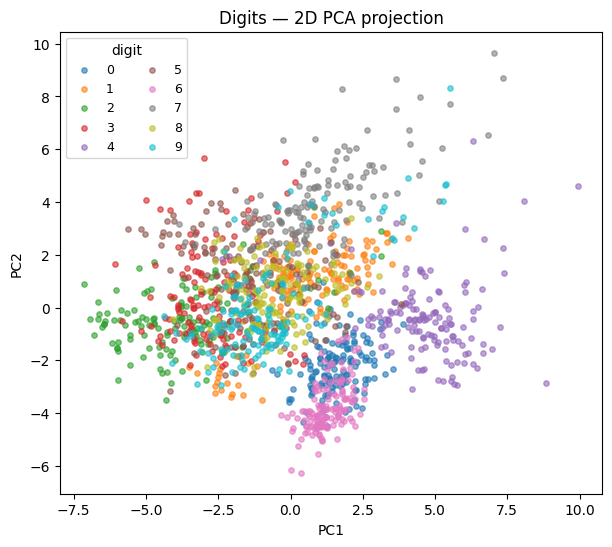

In [6]:
_, comps2, _, _ = pca_fit(X_train_s, n_components=2)
X_train_2d = pca_transform(X_train_s, X_train_s.mean(axis=0, keepdims=True), comps2)

fig, ax = plt.subplots(figsize=(7, 6))
for cls in range(10):
    mask = y_train == cls
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=str(cls), alpha=0.6, s=15)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Digits — 2D PCA projection')
ax.legend(ncol=2, fontsize=9, title='digit')
plt.show()

The clusters of each digit are already partly separated in just 2 dimensions out of 64.

## 7. PCA as preprocessing — speed-up KNN

Compare KNN on raw 64-d features vs on 10-d PCA features.

In [7]:
def time_knn(X_train, X_test, y_train, y_test, k=5):
    t0 = time.perf_counter()
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    pred = m.predict(X_test)
    elapsed = time.perf_counter() - t0
    return accuracy_score(y_test, pred), elapsed

raw_acc, raw_t = time_knn(X_train_s, X_test_s, y_train, y_test)
pca_acc, pca_t = time_knn(sk_train_pcs, sk_test_pcs, y_train, y_test)
print(f'raw 64-d  KNN: accuracy = {raw_acc:.4f}, time = {raw_t * 1000:.1f} ms')
print(f'10-d PCA  KNN: accuracy = {pca_acc:.4f}, time = {pca_t * 1000:.1f} ms')

raw 64-d  KNN: accuracy = 0.9639, time = 14.5 ms
10-d PCA  KNN: accuracy = 0.9444, time = 5.0 ms


On Digits (small dataset) the speed difference is modest, but the *accuracy* survives a 6× compression. On larger datasets the speed advantage grows.

## 8. Reconstruction + denoising demo

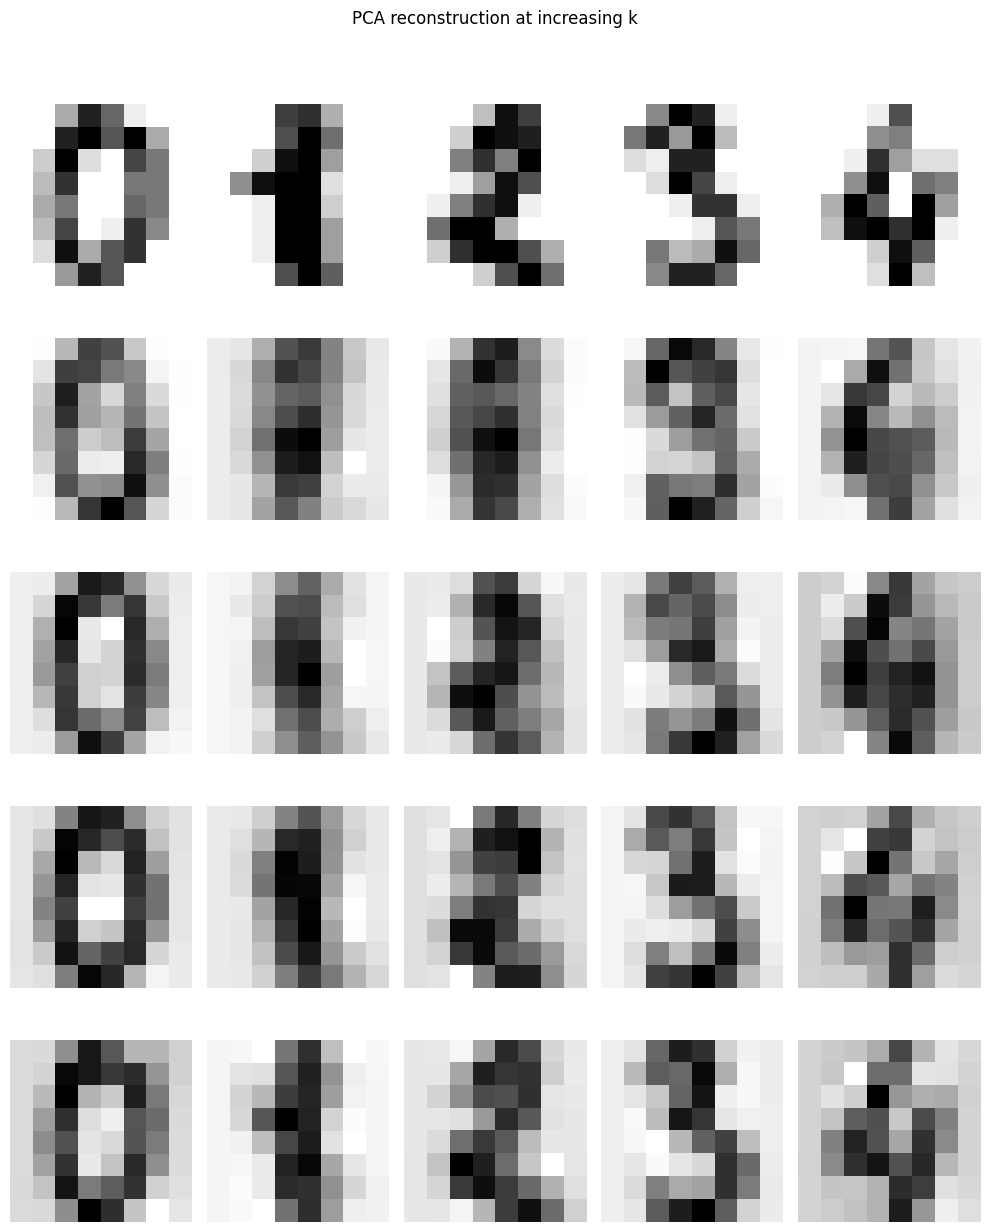

In [8]:
n_show = 5
ks = [2, 5, 10, 20]
fig, axes = plt.subplots(len(ks) + 1, n_show, figsize=(2 * n_show, 2.5 * (len(ks) + 1)))
for c in range(n_show):
    axes[0, c].imshow(digits.images[c], cmap='gray_r'); axes[0, c].axis('off')
    if c == 0: axes[0, c].set_ylabel('original', fontsize=10)
for ri, k in enumerate(ks, start=1):
    pca_k = PCA(n_components=k, random_state=SEED).fit(digits.data)
    reconstructed = pca_k.inverse_transform(pca_k.transform(digits.data[:n_show]))
    for c in range(n_show):
        axes[ri, c].imshow(reconstructed[c].reshape(8, 8), cmap='gray_r')
        axes[ri, c].axis('off')
    axes[ri, 0].set_ylabel(f'k = {k}', fontsize=10)
plt.suptitle('PCA reconstruction at increasing k', y=1.01)
plt.tight_layout(); plt.show()

## 9. Summary

- PCA finds orthogonal directions of maximum variance.
- Implementing PCA via SVD is numerically the right choice — 10 lines of NumPy.
- Cumulative explained variance tells you how many components to keep.
- PCA is great for visualization, denoising, and as a preprocessing step for distance-based models.
- For non-linear manifolds (spirals, multi-cluster shapes), reach for t-SNE or UMAP — out of scope here.